In [4]:
from google.colab import files
uploaded = files.upload()

Saving COPD_DB.csv to COPD_DB.csv


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("COPD_DB.csv")

In [7]:
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 24 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    101 non-null    int64  
 1   ID            101 non-null    int64  
 2   AGE           101 non-null    int64  
 3   PackHistory   101 non-null    float64
 4   COPDSEVERITY  101 non-null    object 
 5   MWT1          99 non-null     float64
 6   MWT2          100 non-null    float64
 7   MWT1Best      100 non-null    float64
 8   FEV1          101 non-null    float64
 9   FEV1PRED      101 non-null    float64
 10  FVC           101 non-null    float64
 11  FVCPRED       101 non-null    int64  
 12  CAT           101 non-null    int64  
 13  HAD           101 non-null    float64
 14  SGRQ          101 non-null    float64
 15  AGEquartiles  101 non-null    int64  
 16  copd          101 non-null    int64  
 17  gender        101 non-null    int64  
 18  smoking       101 non-null    

,0
Unnamed: 0,0
ID,0
AGE,0
PackHistory,0
COPDSEVERITY,0
MWT1,2
MWT2,1
MWT1Best,1
FEV1,0
FEV1PRED,0


In [8]:
df.fillna("Unknown", inplace=True)
df.drop_duplicates(inplace=True)

/tmp/ipykernel_173/2431658153.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.fillna("Unknown", inplace=True)


In [9]:
df = pd.get_dummies(df, drop_first=True)

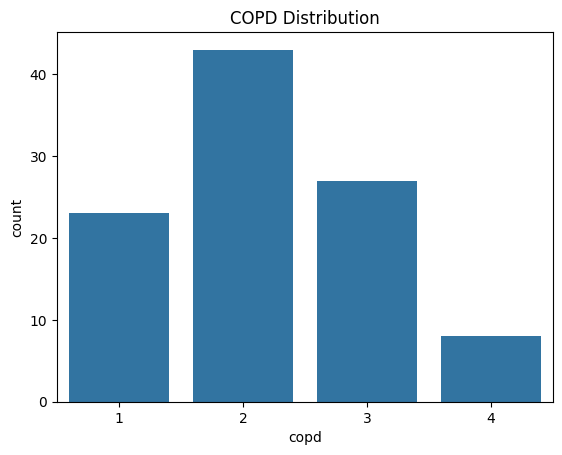

In [10]:
sns.countplot(x='copd', data=df)
plt.title("COPD Distribution")
plt.show()

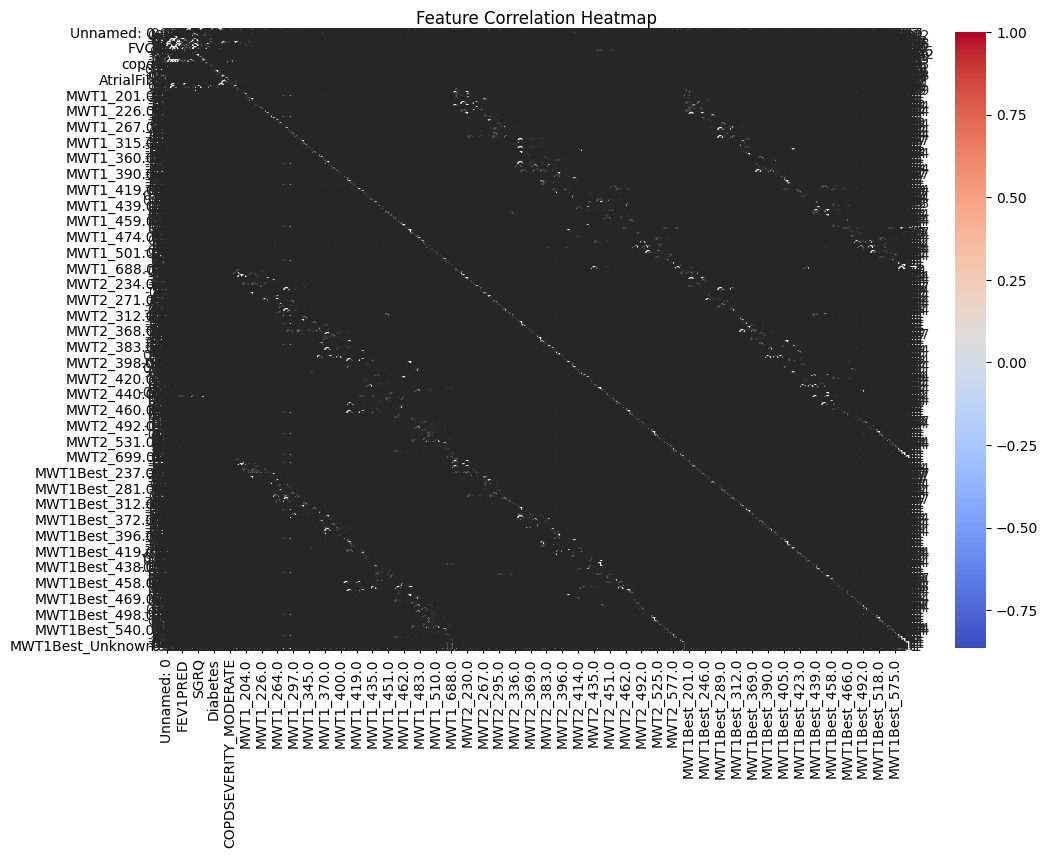

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [12]:
X = df.drop("copd", axis=1)
y = df["copd"]

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

In [28]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Logistic Regression")
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression
[[2 2 1 0]
 [0 5 0 0]
 [0 0 9 0]
 [0 0 1 1]]
              precision    recall  f1-score   support

           1       1.00      0.40      0.57         5
           2       0.71      1.00      0.83         5
           3       0.82      1.00      0.90         9
           4       1.00      0.50      0.67         2

    accuracy                           0.81        21
   macro avg       0.88      0.72      0.74        21
weighted avg       0.85      0.81      0.78        21



In [29]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN")
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN
[[5 0 0 0]
 [5 0 0 0]
 [3 0 6 0]
 [1 0 1 0]]
              precision    recall  f1-score   support

           1       0.36      1.00      0.53         5
           2       0.00      0.00      0.00         5
           3       0.86      0.67      0.75         9
           4       0.00      0.00      0.00         2

    accuracy                           0.52        21
   macro avg       0.30      0.42      0.32        21
weighted avg       0.45      0.52      0.45        21



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [30]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree")
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree
[[4 0 0 1]
 [0 5 0 0]
 [0 0 9 0]
 [0 0 0 2]]
              precision    recall  f1-score   support

           1       1.00      0.80      0.89         5
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00         9
           4       0.67      1.00      0.80         2

    accuracy                           0.95        21
   macro avg       0.92      0.95      0.92        21
weighted avg       0.97      0.95      0.95        21



In [31]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest
[[3 2 0 0]
 [0 5 0 0]
 [0 0 9 0]
 [0 0 0 2]]
              precision    recall  f1-score   support

           1       1.00      0.60      0.75         5
           2       0.71      1.00      0.83         5
           3       1.00      1.00      1.00         9
           4       1.00      1.00      1.00         2

    accuracy                           0.90        21
   macro avg       0.93      0.90      0.90        21
weighted avg       0.93      0.90      0.90        21



In [32]:
svm = SVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM")
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM
[[2 3 0 0]
 [0 5 0 0]
 [0 5 4 0]
 [0 0 1 1]]
              precision    recall  f1-score   support

           1       1.00      0.40      0.57         5
           2       0.38      1.00      0.56         5
           3       0.80      0.44      0.57         9
           4       1.00      0.50      0.67         2

    accuracy                           0.57        21
   macro avg       0.80      0.59      0.59        21
weighted avg       0.77      0.57      0.58        21



In [33]:
from sklearn.metrics import accuracy_score

In [34]:
results = {
    "Logistic Regression": accuracy_score(y_test, y_pred_log),
    "KNN": accuracy_score(y_test, y_pred_knn),
    "Decision Tree": accuracy_score(y_test, y_pred_dt),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "SVM": accuracy_score(y_test, y_pred_svm)
}

results_df = pd.DataFrame(list(results.items()), columns=["Model","Accuracy"])

print(results_df)

                 Model  Accuracy
0  Logistic Regression  0.809524
1                  KNN  0.523810
2        Decision Tree  0.952381
3        Random Forest  0.904762
4                  SVM  0.571429


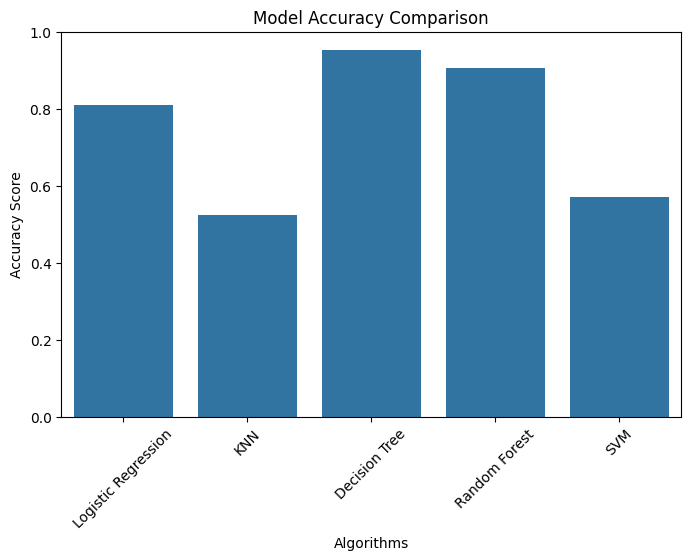

In [35]:


plt.figure(figsize=(8,5))

sns.barplot(x="Model", y="Accuracy", data=results_df)

plt.title("Model Accuracy Comparison")
plt.xlabel("Algorithms")
plt.ylabel("Accuracy Score")
plt.xticks(rotation=45)

plt.show()

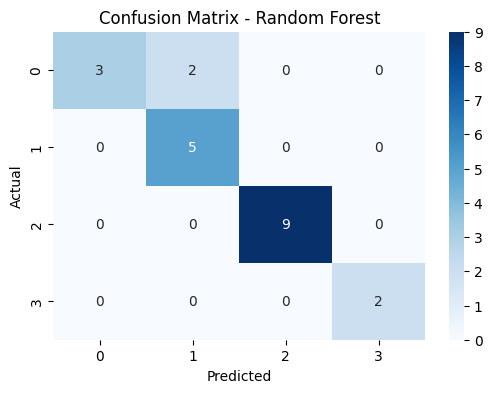

In [37]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics = {
    "Model": ["Logistic Regression","KNN","Decision Tree","Random Forest","SVM"],
    "Precision": [
        precision_score(y_test,y_pred_log, average='weighted'),
        precision_score(y_test,y_pred_knn, average='weighted'),
        precision_score(y_test,y_pred_dt, average='weighted'),
        precision_score(y_test,y_pred_rf, average='weighted'),
        precision_score(y_test,y_pred_svm, average='weighted')
    ],
    "Recall": [
        recall_score(y_test,y_pred_log, average='weighted'),
        recall_score(y_test,y_pred_knn, average='weighted'),
        recall_score(y_test,y_pred_dt, average='weighted'),
        recall_score(y_test,y_pred_rf, average='weighted'),
        recall_score(y_test,y_pred_svm, average='weighted')
    ],
    "F1 Score": [
        f1_score(y_test,y_pred_log, average='weighted'),
        f1_score(y_test,y_pred_knn, average='weighted'),
        f1_score(y_test,y_pred_dt, average='weighted'),
        f1_score(y_test,y_pred_rf, average='weighted'),
        f1_score(y_test,y_pred_svm, average='weighted')
    ]
}

metrics_df = pd.DataFrame(metrics)
print(metrics_df)

                 Model  Precision    Recall  F1 Score
0  Logistic Regression   0.854051  0.809524  0.783673
1                  KNN   0.452381  0.523810  0.446742
2        Decision Tree   0.968254  0.952381  0.954497
3        Random Forest   0.931973  0.904762  0.900794
4                  SVM   0.767766  0.571429  0.576720


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


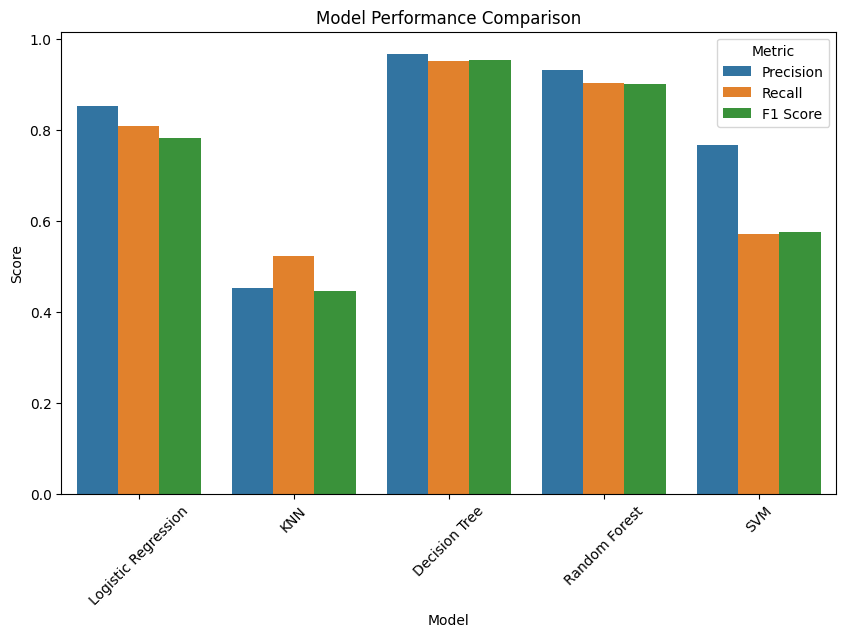

In [39]:
metrics_melted = metrics_df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)


plt.figure(figsize=(10,6))

sns.barplot(
    x="Model",
    y="Score",
    hue="Metric",
    data=metrics_melted
)

plt.title("Model Performance Comparison")
plt.xticks(rotation=45)

plt.show()